How many titles are available on Netflix?

In [2]:
import pandas as pd
df = pd.read_csv('netflix_titles.csv')
print(f"Total Titles in the Dataset: {df.shape[0]}")

Total Titles in the Dataset: 8807


Which countries produce the most content on netflix?

country
United States     3689
India             1046
United Kingdom     804
Canada             445
France             393
Japan              318
Spain              232
South Korea        231
Germany            226
Mexico             169
Name: count, dtype: int64


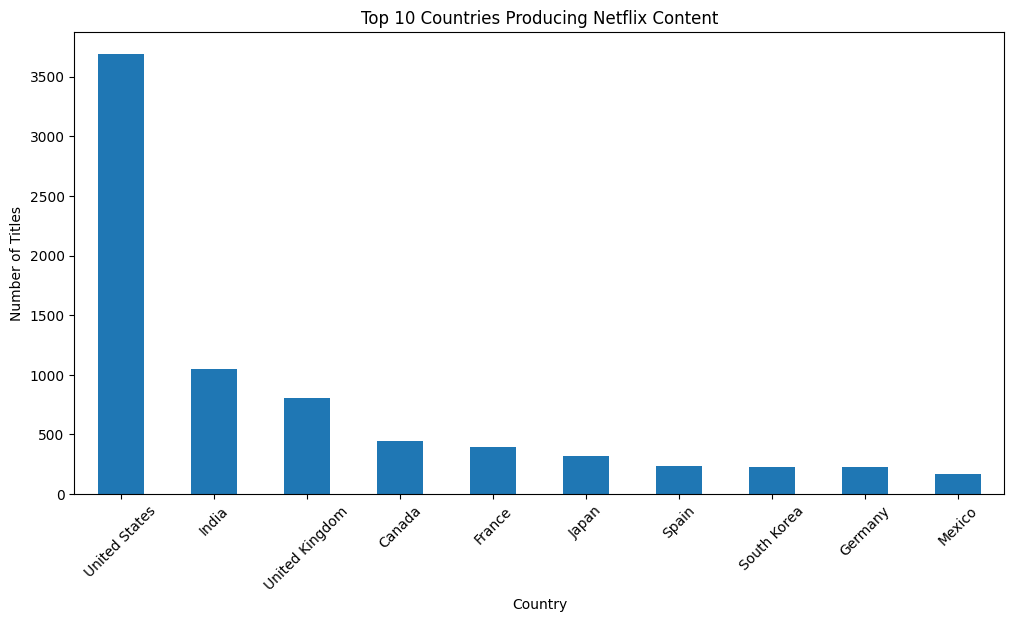

In [3]:
import matplotlib.pyplot as plt

# Split multiple countries and count them
country_counts = (
    df['country']
    .dropna()
    .str.split(', ')
    .explode()
    .value_counts()
)

print(country_counts.head(10))

plt.figure(figsize=(12,6))
country_counts.head(10).plot(kind='bar')
plt.title('Top 10 Countries Producing Netflix Content')
plt.xlabel('Country')
plt.ylabel('Number of Titles')
plt.xticks(rotation=45)
plt.show()

What is the most common content ratings?

In [5]:
df['rating'].value_counts()

,count
rating,
TV-MA,3207
TV-14,2160
TV-PG,863
R,799
PG-13,490
TV-Y7,334
TV-Y,307
PG,287
TV-G,220


**Time-Based Insights**

How has content addition grown over the years?

<Axes: title={'center': 'Netflix Content Added Over the Years'}, xlabel='date_added'>

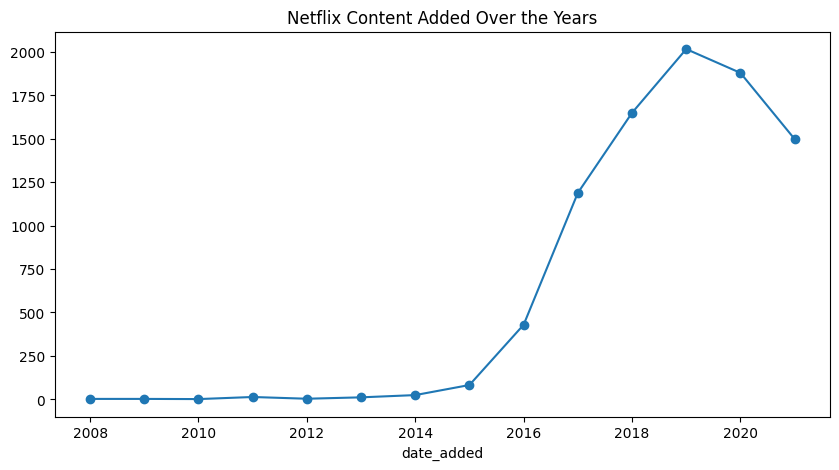

In [7]:
df['date_added'] = pd.to_datetime(df['date_added'], format='mixed'); df['date_added'].dt.year.value_counts().sort_index().plot(figsize=(10,5), marker='o', title='Netflix Content Added Over the Years')

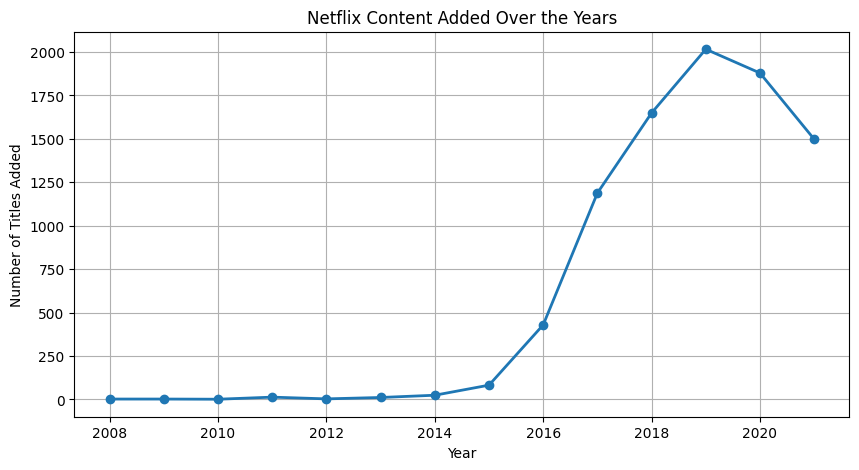

In [8]:
import pandas as pd
import matplotlib.pyplot as plt

# Convert 'date_added' to datetime
df['date_added'] = pd.to_datetime(df['date_added'])

# Count titles added each year
yearly_content = df['date_added'].dt.year.value_counts().sort_index()

# Plot
plt.figure(figsize=(10,5))
plt.plot(yearly_content.index, yearly_content.values, marker='o', linewidth=2)

plt.title('Netflix Content Added Over the Years')
plt.xlabel('Year')
plt.ylabel('Number of Titles Added')
plt.grid(True)
plt.show()

Which year had the highest number of releases?

In [3]:
import pandas as pd

# Load the dataset to ensure 'df' is defined
df = pd.read_csv('netflix_titles.csv')

# Ensure 'date_added' column is in datetime format, handling mixed formats
df['date_added'] = pd.to_datetime(df['date_added'], format='mixed', errors='coerce')

# Count titles added each year
yearly_content = df['date_added'].dt.year.value_counts().sort_index()

# Find the year with the highest number of releases
year_highest_releases = yearly_content.idxmax()
num_highest_releases = yearly_content.max()

print(f"The year with the highest number of releases is {year_highest_releases} with {num_highest_releases} titles added.")

The year with the highest number of releases is 2019.0 with 2016 titles added.


Is Netflix adding more Movies or Tv Shows in recent years?

### Content Type Trends Over Recent Years

To understand if Netflix is adding more movies or TV shows, we will analyze the content additions by type for recent years.

<Figure size 1200x600 with 0 Axes>

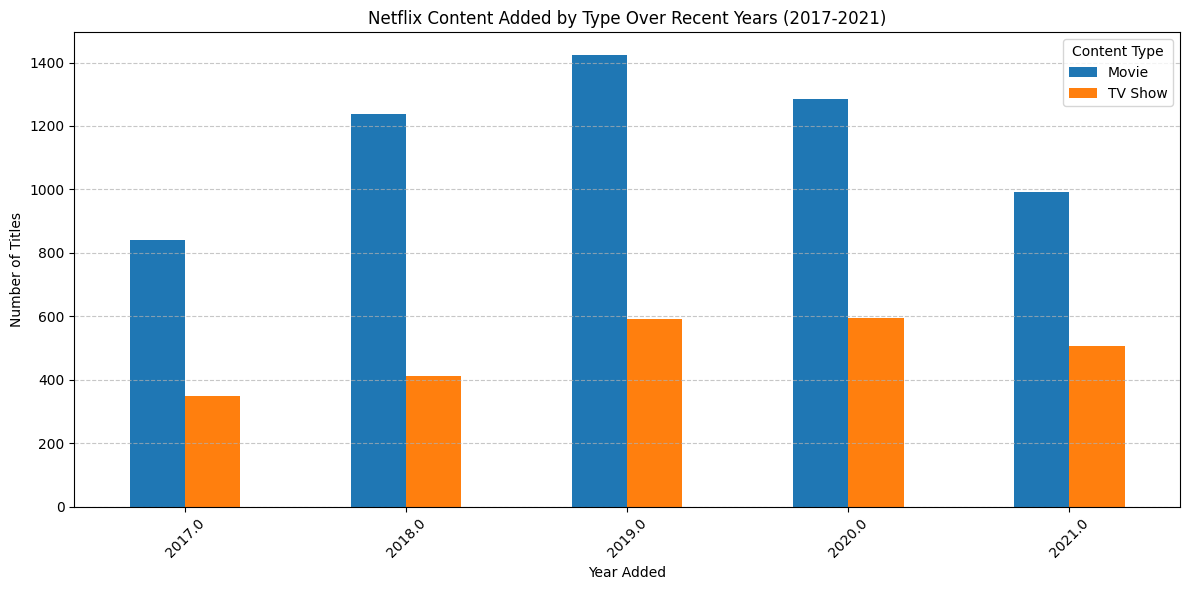

type,Movie,TV Show
year_added,,
2017.0,839,349
2018.0,1237,412
2019.0,1424,592
2020.0,1284,595
2021.0,993,505


In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# Extract the year from 'date_added'
df['year_added'] = df['date_added'].dt.year

# Filter for recent years (e.g., the last 5 years with significant data)
# Based on yearly_content, years from 2017 onwards seem to have significant additions
recent_years_df = df[df['year_added'] >= 2017]

# Group by year and type, then count titles
content_type_by_year = recent_years_df.groupby(['year_added', 'type']).size().unstack(fill_value=0)

# Plotting the trend
plt.figure(figsize=(12, 6))
content_type_by_year.plot(kind='bar', figsize=(12, 6))
plt.title('Netflix Content Added by Type Over Recent Years (2017-2021)')
plt.xlabel('Year Added')
plt.ylabel('Number of Titles')
plt.xticks(rotation=45)
plt.legend(title='Content Type')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Display the aggregated data
display(content_type_by_year)

### Content Types by Top Producing Countries

To understand the production strategy of top content-producing countries, let's analyze the distribution of Movies versus TV Shows from the top 5 countries.

<Figure size 1400x700 with 0 Axes>

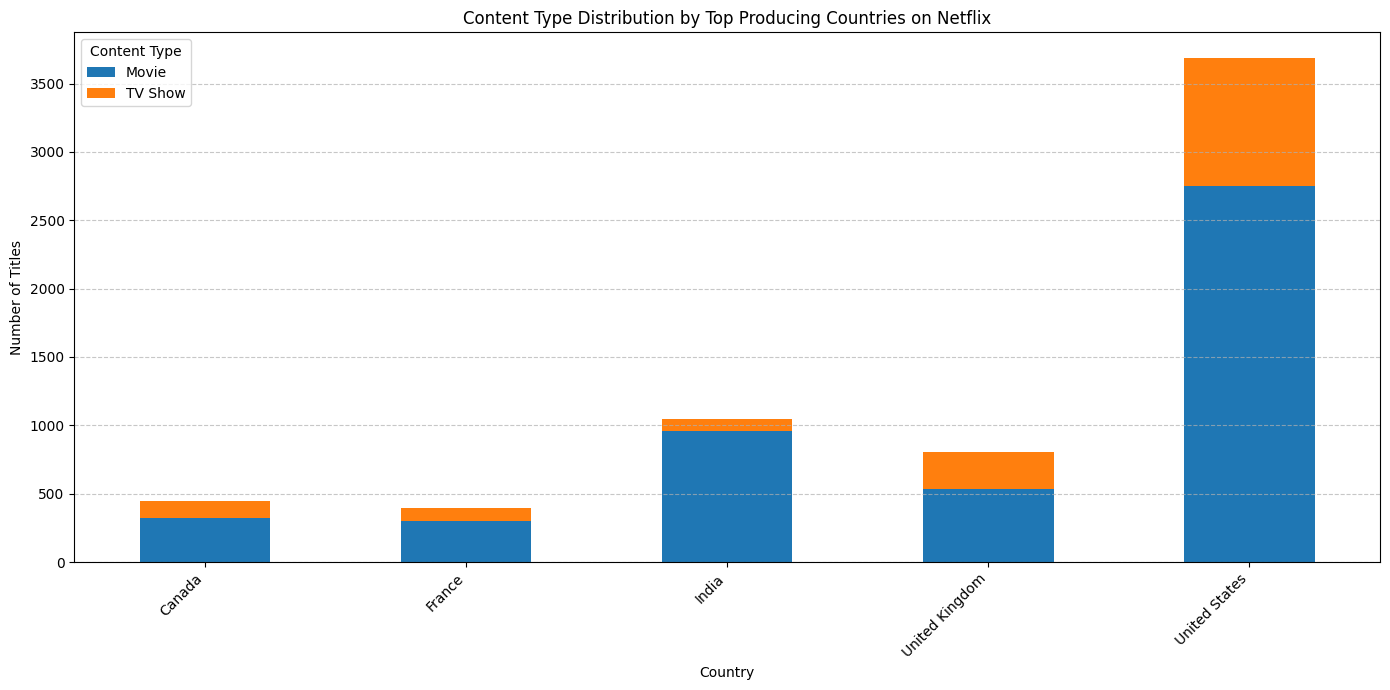

type,Movie,TV Show
country_list,,
Canada,319,126
France,303,90
India,962,84
United Kingdom,534,272
United States,2752,938


In [8]:
# Ensure df is loaded and 'country' column is clean before proceeding
# (Assuming df is already loaded in previous cells, but adding for robustness if run independently)
# If 'df' is not defined, you might need to run the data loading cell first.

# Split multiple countries and count them to identify top countries
country_counts = (
    df['country']
    .dropna()
    .str.split(', ')
    .explode()
    .value_counts()
)

# Get the top N countries (e.g., top 5)
top_countries = country_counts.head(5).index.tolist()

# Prepare for detailed country-content type analysis:
# First, handle multiple countries per title by exploding the 'country' column.
# Create a temporary column to hold split countries
df_temp = df.copy()
df_temp['country_list'] = df_temp['country'].dropna().apply(lambda x: [c.strip() for c in x.split(',')])
df_exploded_countries = df_temp.explode('country_list')

# Now filter this exploded DataFrame to include only the top countries
df_top_exploded = df_exploded_countries[df_exploded_countries['country_list'].isin(top_countries)]

# Group by the individual country (from 'country_list') and content type, then count titles
country_content_type = df_top_exploded.groupby(['country_list', 'type']).size().unstack(fill_value=0)

# Plotting the stacked bar chart
plt.figure(figsize=(14, 7))
country_content_type.plot(kind='bar', stacked=True, figsize=(14, 7))
plt.title('Content Type Distribution by Top Producing Countries on Netflix')
plt.xlabel('Country')
plt.ylabel('Number of Titles')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Content Type')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Display the aggregated data
display(country_content_type)

<Figure size 1200x600 with 0 Axes>

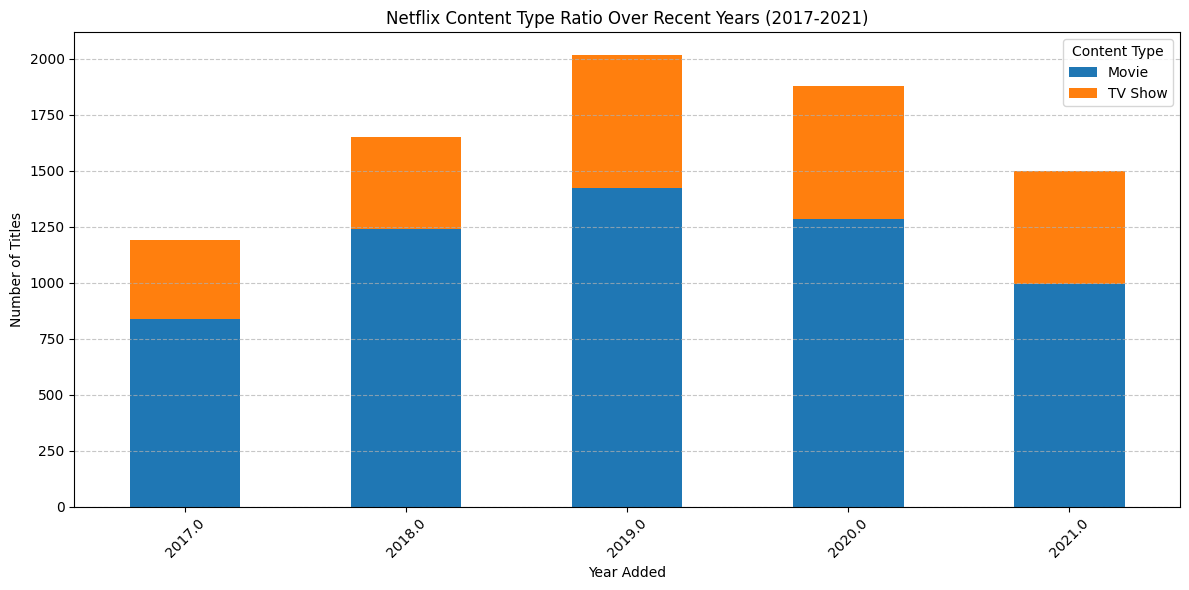

In [5]:
plt.figure(figsize=(12, 6))
content_type_by_year.plot(kind='bar', stacked=True, figsize=(12, 6))
plt.title('Netflix Content Type Ratio Over Recent Years (2017-2021)')
plt.xlabel('Year Added')
plt.ylabel('Number of Titles')
plt.xticks(rotation=45)
plt.legend(title='Content Type')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

**Complete Dashboard**

In [9]:
# NETFLIX DASHBOARD - PART 1


import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import plotly.express as px
import plotly.graph_objects as go

from plotly.subplots import make_subplots

# Dashboard Theme
plt.style.use("ggplot")
sns.set_palette("Set2")

In [10]:
# Load Dataset
df = pd.read_csv("netflix_titles.csv")

# Preview
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [11]:
print("="*50)
print("Dataset Shape :", df.shape)
print("="*50)

display(df.info())

display(df.describe(include="all"))

Dataset Shape : (8807, 12)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


None

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
count,8807,8807,8807,6173,7982,7976,8797,8807.000000,8803,8804,8807,8807
unique,8807,2,8807,4528,7692,748,1767,NaN,17,220,514,8775
top,s8807,Movie,Zubaan,Rajiv Chilaka,David Attenborough,United States,"January 1, 2020",NaN,TV-MA,1 Season,"Dramas, International Movies","Paranormal activity at a lush, abandoned prope..."
freq,1,6131,1,19,19,2818,109,NaN,3207,1793,362,4
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2014.180198,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.819312,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1925.000000,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2013.000000,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2017.000000,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2019.000000,NaN,NaN,NaN,NaN


In [12]:
missing = (
    df.isnull()
      .sum()
      .sort_values(ascending=False)
      .reset_index()
)

missing.columns = ["Column","Missing Values"]

missing

,Column,Missing Values
0,director,2634
1,country,831
2,cast,825
3,date_added,10
4,rating,4
5,duration,3
6,show_id,0
7,type,0
8,title,0
9,release_year,0


In [13]:
print("Duplicate Rows :", df.duplicated().sum())

Duplicate Rows : 0


In [15]:
df["date_added"] = pd.to_datetime(df["date_added"], format='mixed', errors='coerce')

In [16]:
df["Year Added"] = df["date_added"].dt.year
df["Month Added"] = df["date_added"].dt.month_name()

***TOTAL TITLES***

In [17]:
total_titles = df.shape[0]

In [18]:
movies = (df["type"]=="Movie").sum()

In [19]:
tvshows = (df["type"]=="TV Show").sum()


In [20]:
countries = df["country"].dropna().str.split(", ").explode().nunique()

In [21]:
genres = df["listed_in"].str.split(", ").explode().nunique()

In [22]:
directors = df["director"].dropna().str.split(", ").explode().nunique()

In [23]:
top_rating = df["rating"].mode()[0]

In [24]:
latest_year = df["release_year"].max()

***KPI CARDS***

In [25]:
kpi = pd.DataFrame({
    "Metric":[
        "Total Titles",
        "Movies",
        "TV Shows",
        "Countries",
        "Genres",
        "Directors",
        "Top Rating",
        "Latest Release"
    ],
    "Value":[
        total_titles,
        movies,
        tvshows,
        countries,
        genres,
        directors,
        top_rating,
        latest_year
    ]
})

kpi

,Metric,Value
0,Total Titles,8807
1,Movies,6131
2,TV Shows,2676
3,Countries,127
4,Genres,42
5,Directors,4993
6,Top Rating,TV-MA
7,Latest Release,2021


***DashBoard With KPI Cards***

In [26]:
print("="*60)
print("📺 NETFLIX CONTENT DASHBOARD")
print("="*60)

for i in range(len(kpi)):
    print(f"{kpi.iloc[i,0]:20}: {kpi.iloc[i,1]}")

📺 NETFLIX CONTENT DASHBOARD
Total Titles        : 8807
Movies              : 6131
TV Shows            : 2676
Countries           : 127
Genres              : 42
Directors           : 4993
Top Rating          : TV-MA
Latest Release      : 2021


***Movies vs TV Shows (Donut Chart)***

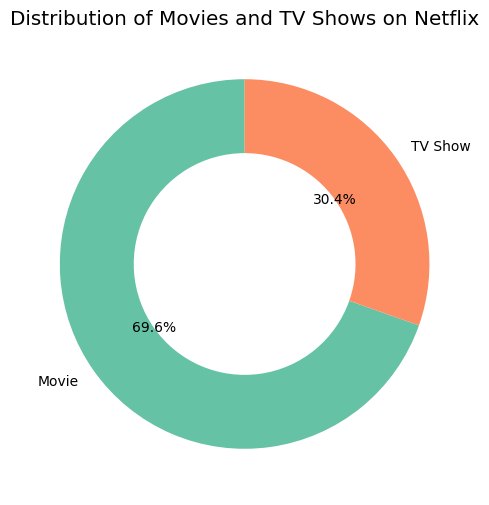

In [27]:
# Count Movies and TV Shows
type_counts = df['type'].value_counts()

# Plot Donut Chart
plt.figure(figsize=(6,6))

plt.pie(
    type_counts,
    labels=type_counts.index,
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops=dict(width=0.4)
)

plt.title("Distribution of Movies and TV Shows on Netflix")
plt.show()

**Business Insight**

In [28]:
movie_pct = round((movies / total_titles) * 100, 1)
tv_pct = round((tvshows / total_titles) * 100, 1)

print(f"🎬 Movies account for {movie_pct}% of Netflix's catalog.")
print(f"📺 TV Shows account for {tv_pct}% of Netflix's catalog.")

🎬 Movies account for 69.6% of Netflix's catalog.
📺 TV Shows account for 30.4% of Netflix's catalog.


***Content Added Over the Years***

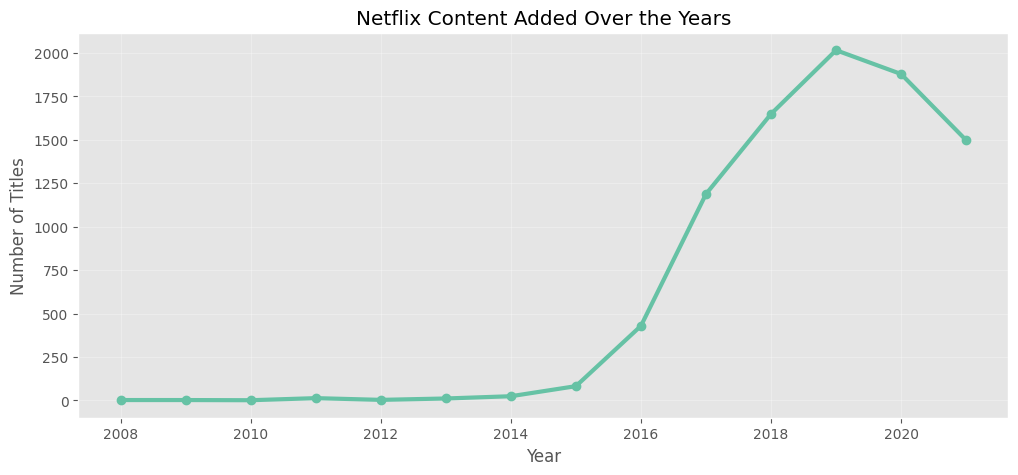

In [29]:
# Count content added each year
yearly_content = (
    df['Year Added']
    .value_counts()
    .sort_index()
)

plt.figure(figsize=(12,5))

plt.plot(
    yearly_content.index,
    yearly_content.values,
    marker='o',
    linewidth=3
)

plt.title("Netflix Content Added Over the Years")
plt.xlabel("Year")
plt.ylabel("Number of Titles")
plt.grid(alpha=0.3)

plt.show()

# *Business Insight*

In [30]:
peak_year = yearly_content.idxmax()
peak_titles = yearly_content.max()

print(f"📈 Netflix added the highest number of titles in {peak_year} ({peak_titles} titles).")

📈 Netflix added the highest number of titles in 2019.0 (2016 titles).


***Content Added by Month***

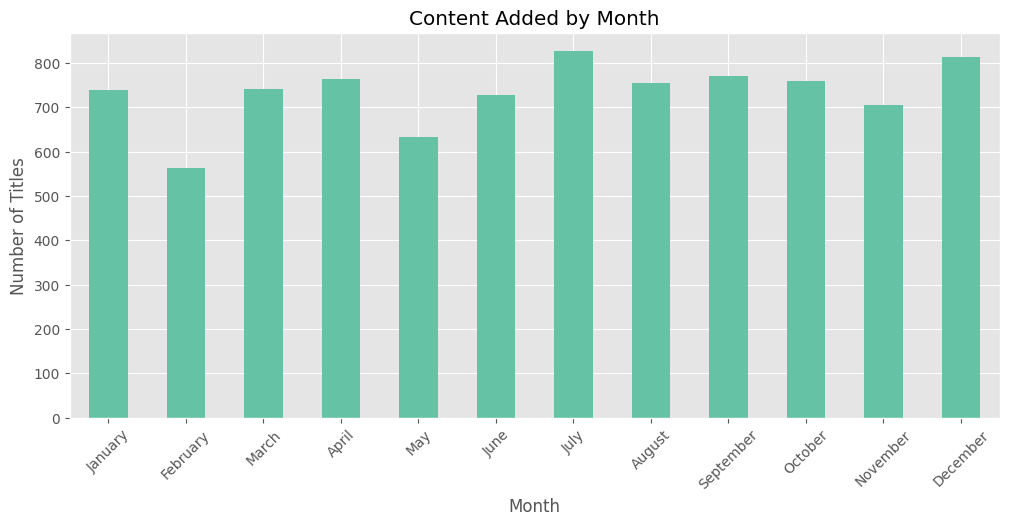

In [31]:
# Order months correctly
month_order = [
    'January','February','March','April',
    'May','June','July','August',
    'September','October','November','December'
]

monthly_content = (
    df['Month Added']
    .value_counts()
    .reindex(month_order)
)

plt.figure(figsize=(12,5))

monthly_content.plot(kind='bar')

plt.title("Content Added by Month")
plt.xlabel("Month")
plt.ylabel("Number of Titles")
plt.xticks(rotation=45)

plt.show()

**Business Insight**

In [32]:
best_month = monthly_content.idxmax()
titles = monthly_content.max()

print(f"📅 Netflix added the most content in {best_month} ({titles} titles).")

📅 Netflix added the most content in July (827 titles).


## ***Summary Dashboard***




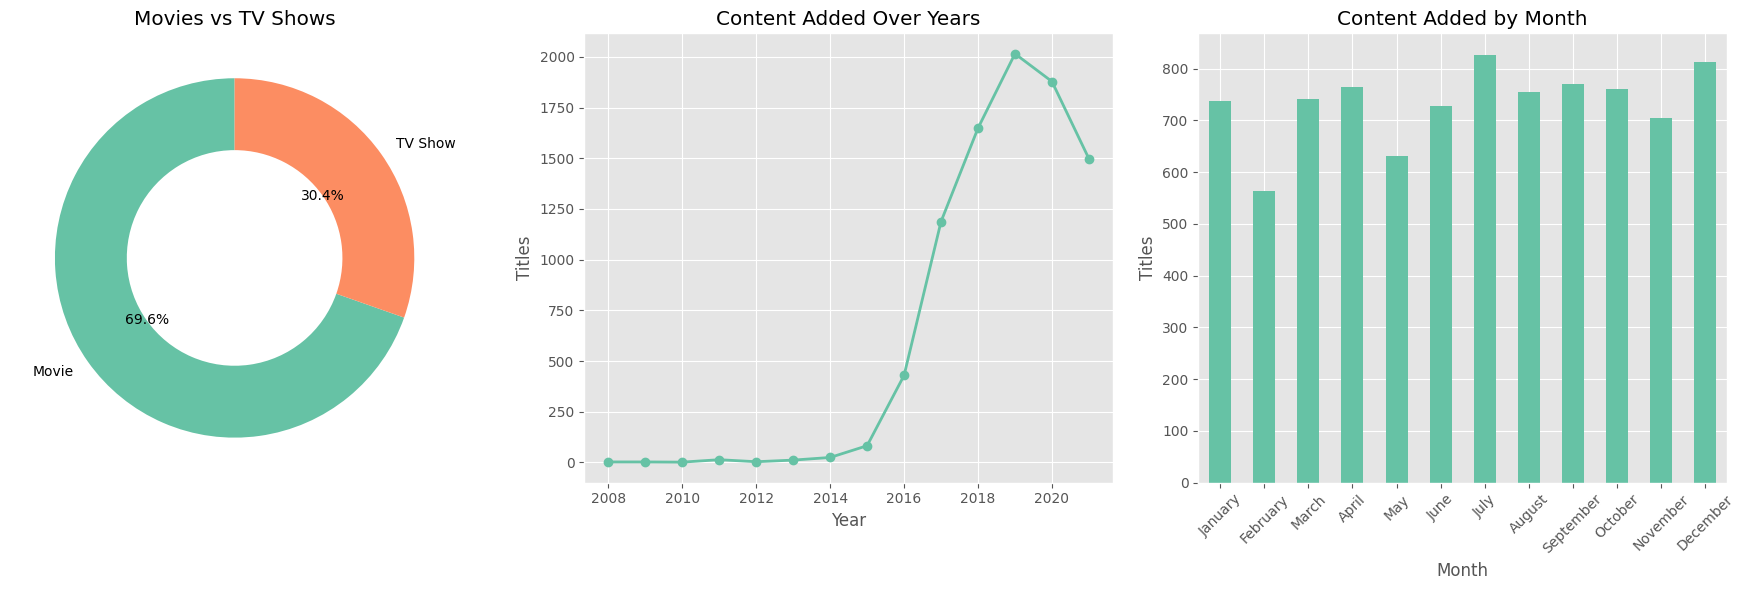

In [33]:
fig, axes = plt.subplots(1, 3, figsize=(18,6))

# Movies vs TV Shows
axes[0].pie(
    type_counts,
    labels=type_counts.index,
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops=dict(width=0.4)
)
axes[0].set_title("Movies vs TV Shows")

# Yearly Content
axes[1].plot(
    yearly_content.index,
    yearly_content.values,
    marker='o',
    linewidth=2
)
axes[1].set_title("Content Added Over Years")
axes[1].set_xlabel("Year")
axes[1].set_ylabel("Titles")

# Monthly Content
monthly_content.plot(kind='bar', ax=axes[2])
axes[2].set_title("Content Added by Month")
axes[2].set_xlabel("Month")
axes[2].set_ylabel("Titles")
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# ***Top 10 Content-Producing Countries***

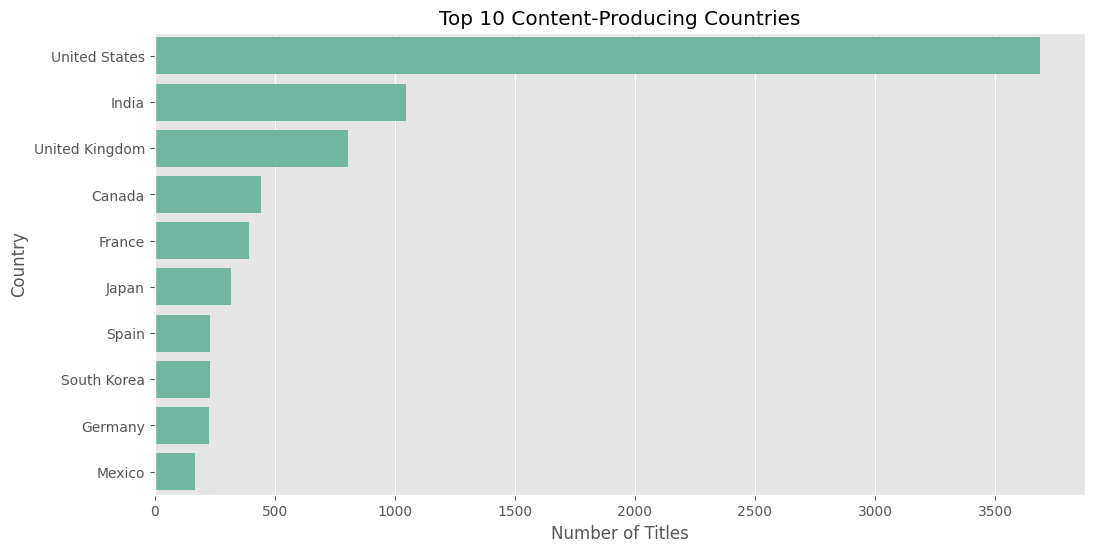

In [34]:
# Split multiple countries into individual rows
country_df = (
    df.assign(country=df['country'].str.split(', '))
      .explode('country')
)

# Count titles by country
top_countries = country_df['country'].value_counts().head(10)

# Plot
plt.figure(figsize=(12,6))

sns.barplot(
    x=top_countries.values,
    y=top_countries.index
)

plt.title("Top 10 Content-Producing Countries")
plt.xlabel("Number of Titles")
plt.ylabel("Country")

plt.show()

Business Insight

In [35]:
print("Top 10 Content-Producing Countries")
display(top_countries)

Top 10 Content-Producing Countries


,count
country,
United States,3689
India,1046
United Kingdom,804
Canada,445
France,393
Japan,318
Spain,232
South Korea,231
Germany,226


Movies vs TV Shows by **Country**

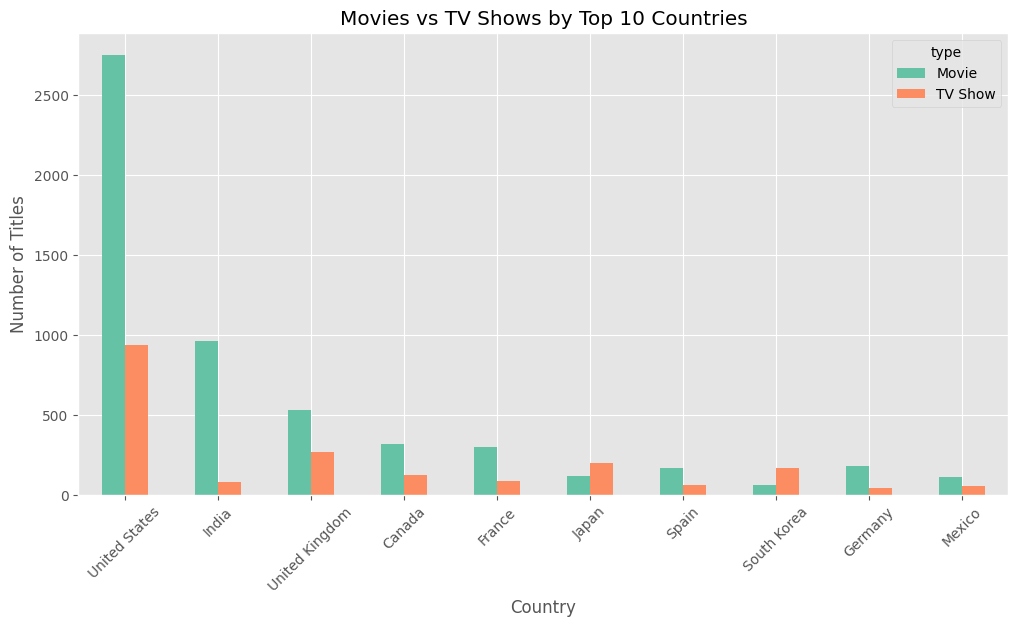

In [36]:
country_type = (
    country_df
    .groupby(['country','type'])
    .size()
    .unstack(fill_value=0)
)

top10 = country_df['country'].value_counts().head(10).index

country_type.loc[top10].plot(
    kind='bar',
    figsize=(12,6)
)

plt.title("Movies vs TV Shows by Top 10 Countries")
plt.xlabel("Country")
plt.ylabel("Number of Titles")
plt.xticks(rotation=45)

plt.show()

In [37]:
display(country_type.loc[top10])

type,Movie,TV Show
country,,
United States,2751,938
India,962,84
United Kingdom,532,272
Canada,319,126
France,303,90
Japan,119,199
Spain,171,61
South Korea,61,170
Germany,182,44


Top 10 Countries Percentage Share

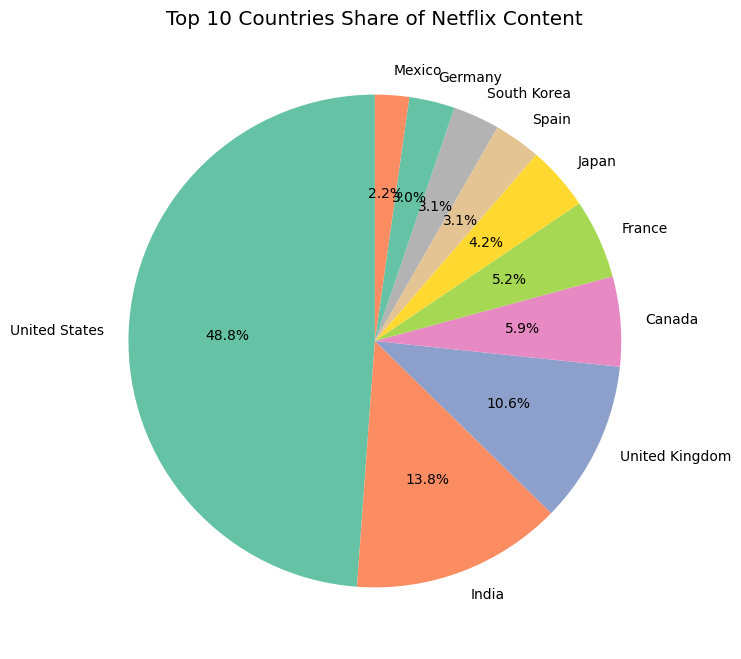

In [38]:
country_percent = (
    country_df['country']
    .value_counts(normalize=True)
    .head(10)
    *100
)

plt.figure(figsize=(8,8))

plt.pie(
    country_percent,
    labels=country_percent.index,
    autopct='%1.1f%%',
    startangle=90
)

plt.title("Top 10 Countries Share of Netflix Content")

plt.show()

# ***Dashboard View***

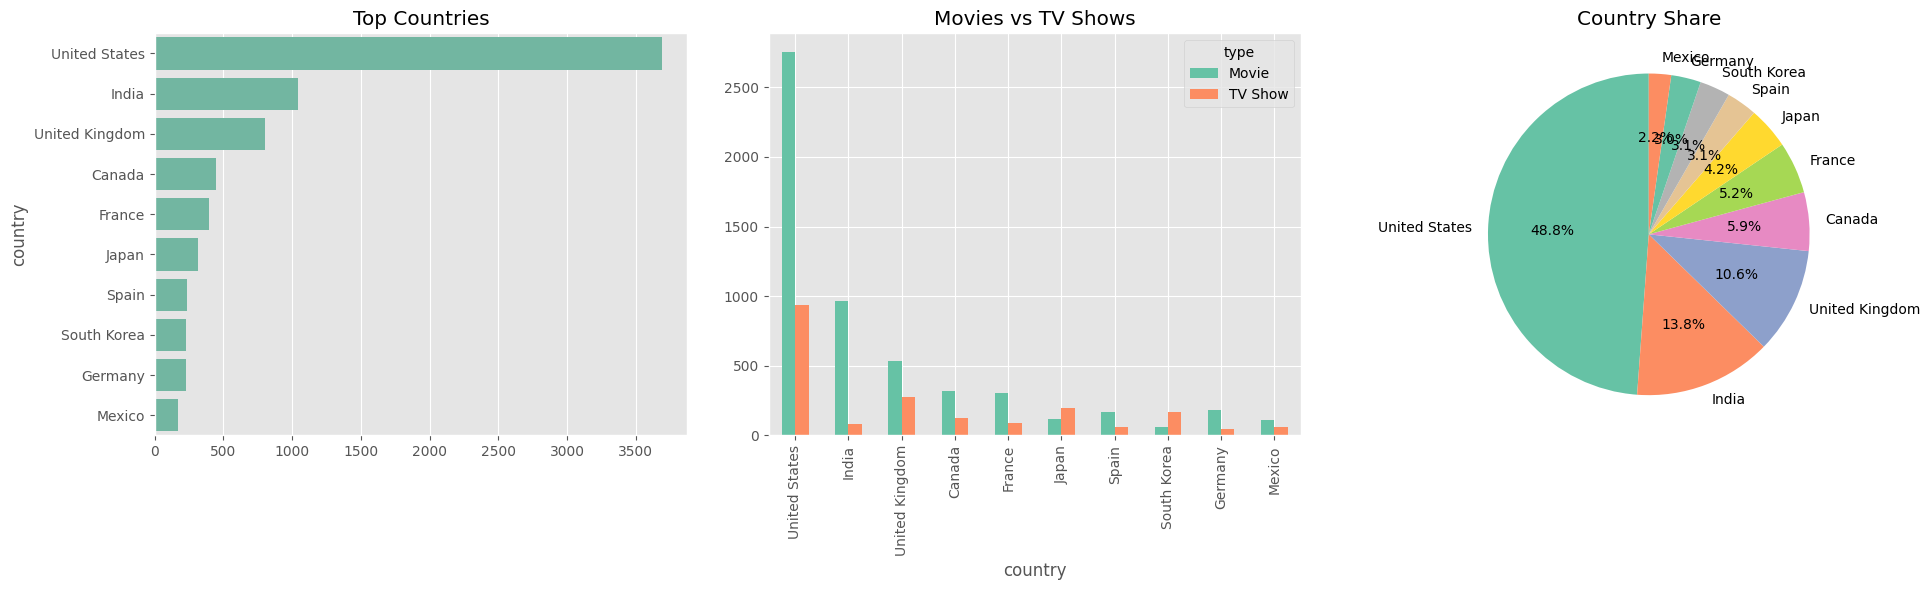

In [39]:
fig, axes = plt.subplots(1,3,figsize=(20,6))

# Top Countries
sns.barplot(
    x=top_countries.values,
    y=top_countries.index,
    ax=axes[0]
)
axes[0].set_title("Top Countries")

# Movies vs TV Shows
country_type.loc[top10].plot(
    kind='bar',
    ax=axes[1]
)
axes[1].set_title("Movies vs TV Shows")

# Country Share
axes[2].pie(
    country_percent,
    labels=country_percent.index,
    autopct='%1.1f%%',
    startangle=90
)
axes[2].set_title("Country Share")

plt.tight_layout()

plt.show()

In [40]:
print("="*70)
print("🌍 Geographic Analysis Insights")
print("="*70)

print(f"🏆 Highest content-producing country : {top_countries.idxmax()} ({top_countries.max()} titles)")
print(f"🌎 Total Countries Represented : {country_df['country'].nunique()}")
print(f"🎬 Top 10 countries contribute {round(country_percent.sum(),1)}% of Netflix content.")

🌍 Geographic Analysis Insights
🏆 Highest content-producing country : United States (3689 titles)
🌎 Total Countries Represented : 127
🎬 Top 10 countries contribute 75.4% of Netflix content.


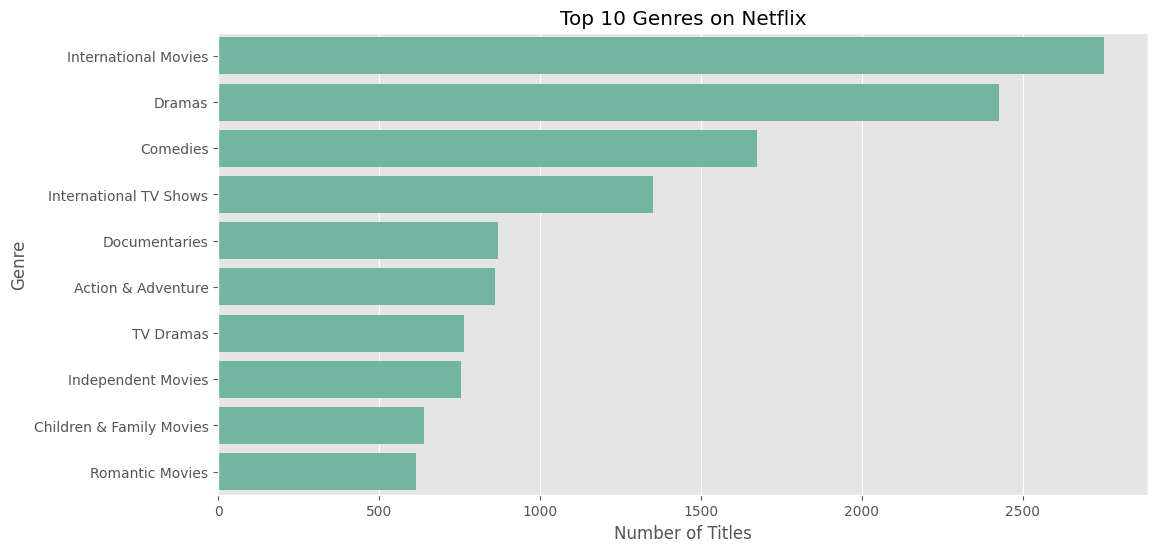

In [42]:
# Split genres into separate rows
genre_df = (
    df.assign(listed_in=df['listed_in'].str.split(', '))
      .explode('listed_in')
)

top_genres = genre_df['listed_in'].value_counts().head(10)

plt.figure(figsize=(12,6))

sns.barplot(
    x=top_genres.values,
    y=top_genres.index
)

plt.title("Top 10 Genres on Netflix")
plt.xlabel("Number of Titles")
plt.ylabel("Genre")

plt.show()

In [43]:
print("Top 10 Genres")
display(top_genres)

Top 10 Genres


,count
listed_in,
International Movies,2752
Dramas,2427
Comedies,1674
International TV Shows,1351
Documentaries,869
Action & Adventure,859
TV Dramas,763
Independent Movies,756
Children & Family Movies,641


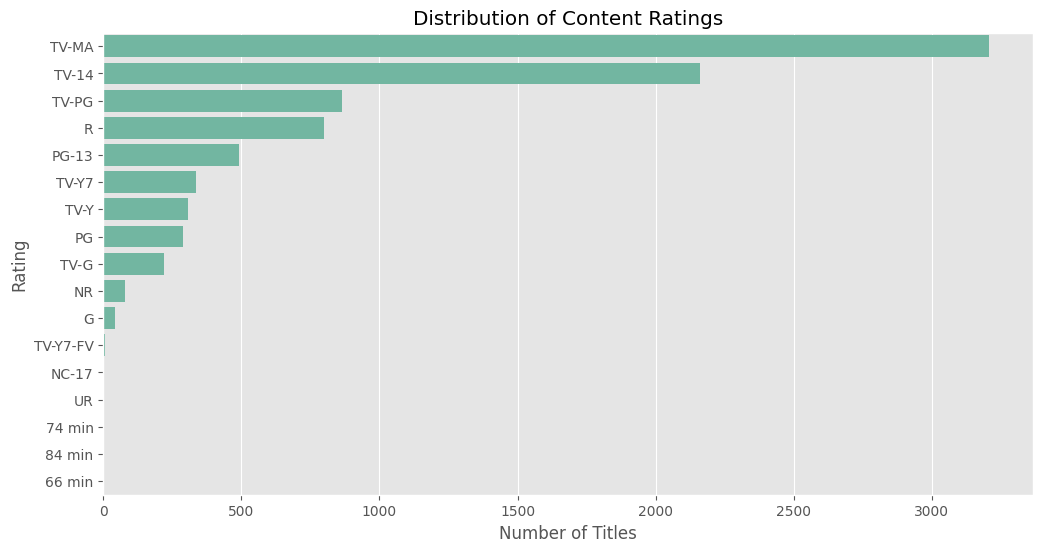

In [44]:
plt.figure(figsize=(12,6))

sns.countplot(
    data=df,
    y='rating',
    order=df['rating'].value_counts().index
)

plt.title("Distribution of Content Ratings")
plt.xlabel("Number of Titles")
plt.ylabel("Rating")

plt.show()

In [45]:
print(f"Most Common Rating : {df['rating'].mode()[0]}")

Most Common Rating : TV-MA


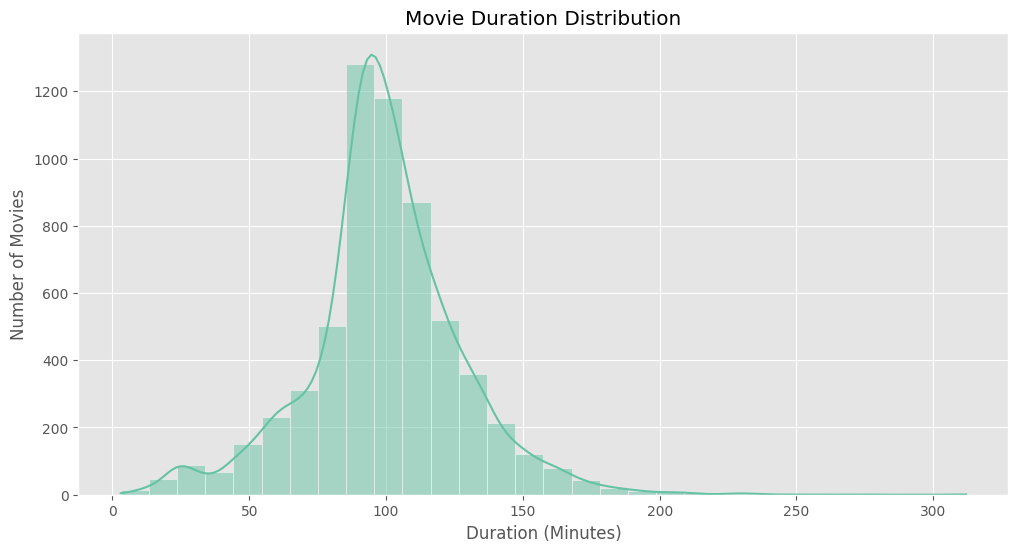

In [47]:
# Movie durations
movies_df = df[df['type']=='Movie'].copy()

# Clean 'duration' column: remove ' min' string
movies_df['duration'] = movies_df['duration'].str.replace(' min','', regex=False)

# Convert to numeric, coercing any unparseable values (including original NaNs) to NaN
movies_df['duration'] = pd.to_numeric(movies_df['duration'], errors='coerce')

# Drop rows where 'duration' is NaN after cleaning and conversion
movies_df.dropna(subset=['duration'], inplace=True)

# Convert to integer type
movies_df['duration'] = movies_df['duration'].astype(int)

plt.figure(figsize=(12,6))

sns.histplot(
    movies_df['duration'],
    bins=30,
    kde=True
)

plt.title("Movie Duration Distribution")
plt.xlabel("Duration (Minutes)")
plt.ylabel("Number of Movies")

plt.show()

In [48]:
print("Average Movie Duration :", round(movies_df['duration'].mean(),1), "minutes")

Average Movie Duration : 99.6 minutes


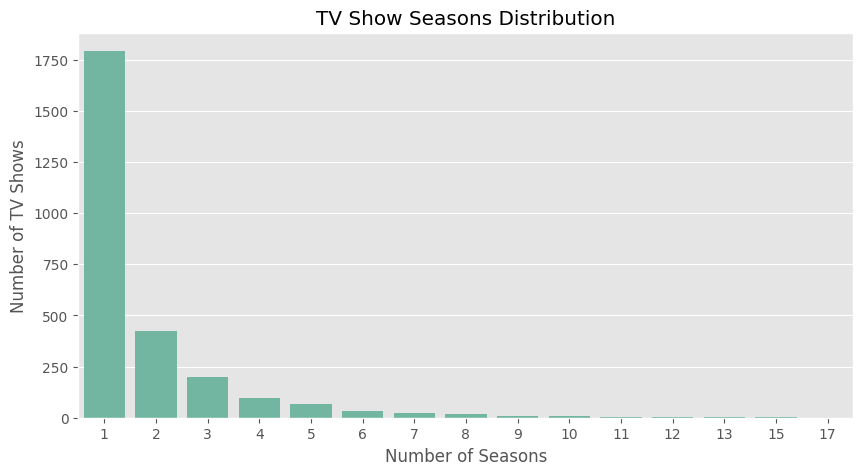

In [49]:
tv_df = df[df['type']=='TV Show'].copy()

tv_df['duration'] = (
    tv_df['duration']
    .str.replace(' Seasons','', regex=False)
    .str.replace(' Season','', regex=False)
    .astype(int)
)

plt.figure(figsize=(10,5))

sns.countplot(
    data=tv_df,
    x='duration'
)

plt.title("TV Show Seasons Distribution")
plt.xlabel("Number of Seasons")
plt.ylabel("Number of TV Shows")

plt.show()

In [50]:
print("Average Seasons :", round(tv_df['duration'].mean(),2))

Average Seasons : 1.76


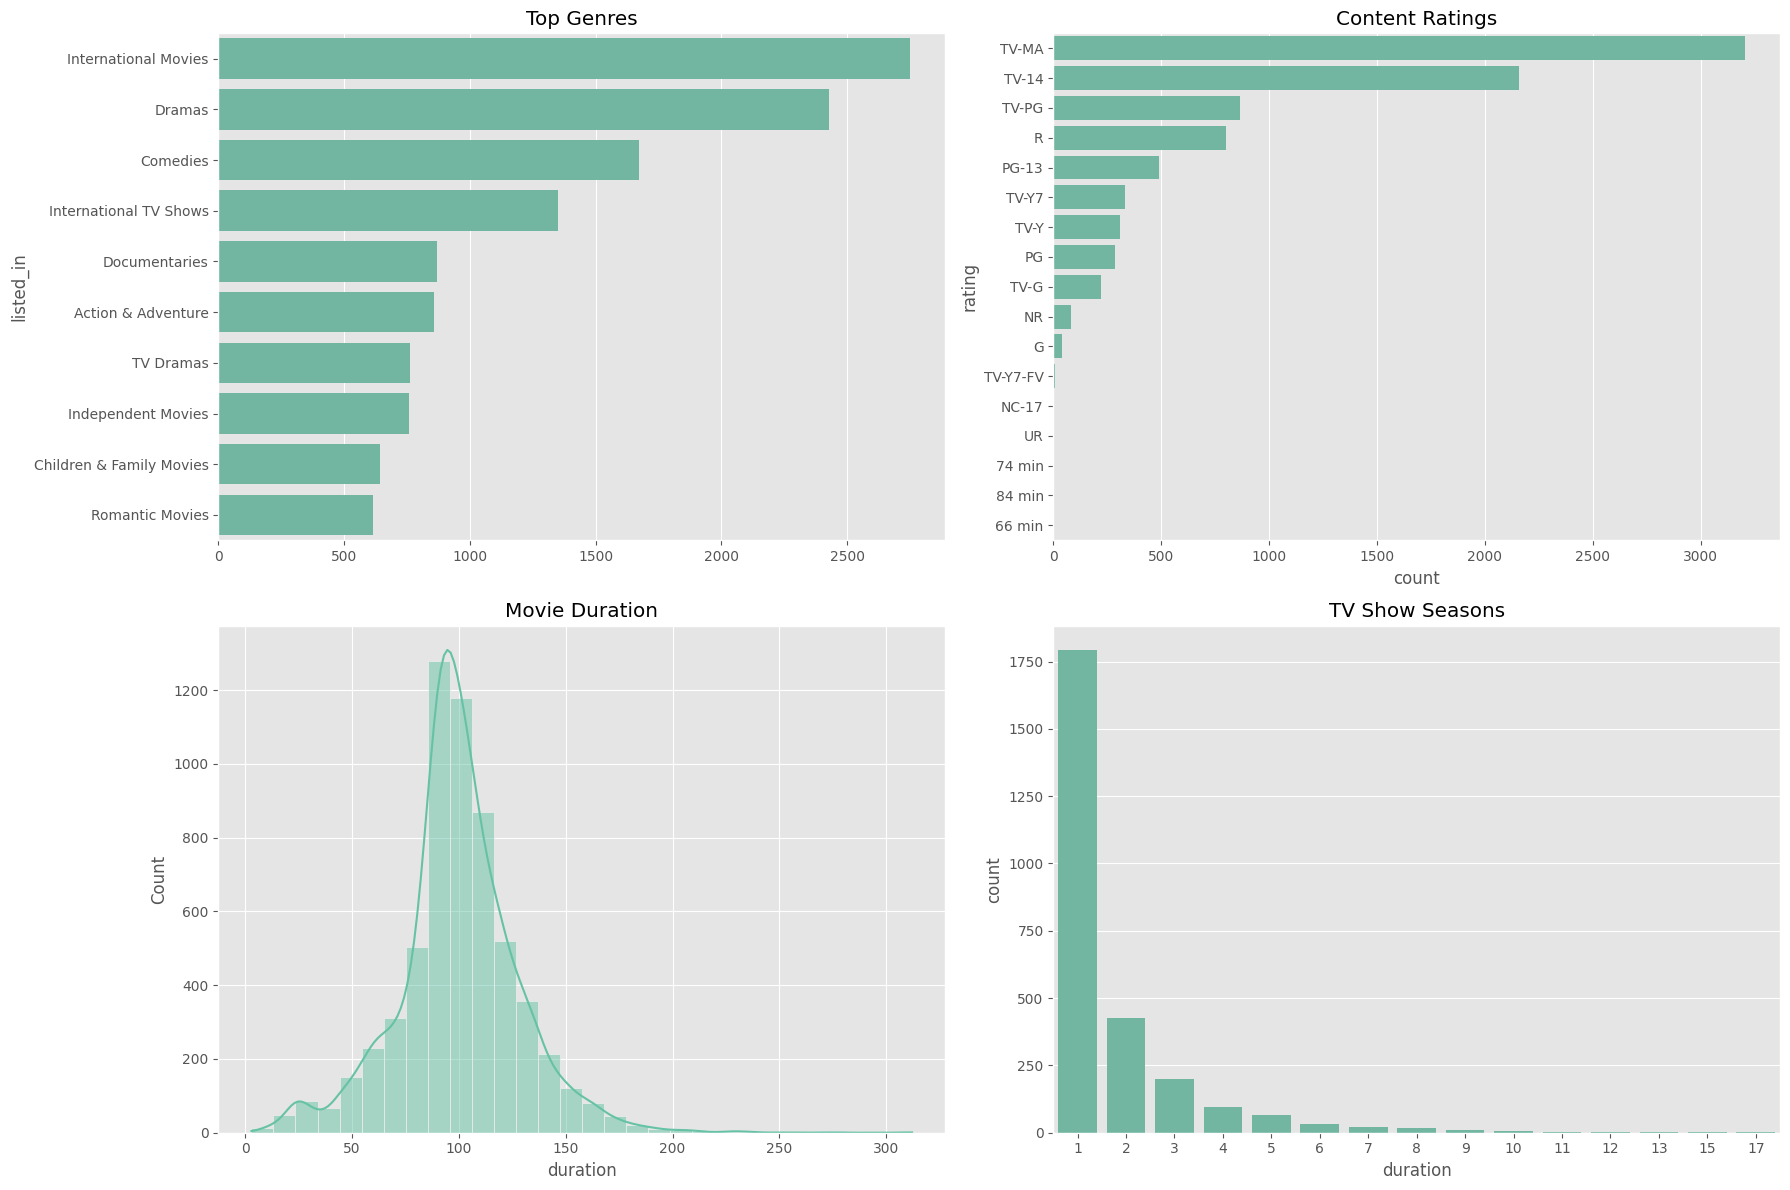

In [51]:
fig, axes = plt.subplots(2,2,figsize=(18,12))

# Top Genres
sns.barplot(
    x=top_genres.values,
    y=top_genres.index,
    ax=axes[0,0]
)
axes[0,0].set_title("Top Genres")

# Ratings
sns.countplot(
    data=df,
    y='rating',
    order=df['rating'].value_counts().index,
    ax=axes[0,1]
)
axes[0,1].set_title("Content Ratings")

# Movie Duration
sns.histplot(
    movies_df['duration'],
    bins=30,
    kde=True,
    ax=axes[1,0]
)
axes[1,0].set_title("Movie Duration")

# TV Seasons
sns.countplot(
    data=tv_df,
    x='duration',
    ax=axes[1,1]
)
axes[1,1].set_title("TV Show Seasons")

plt.tight_layout()
plt.show()

# **Time & People Analysis**

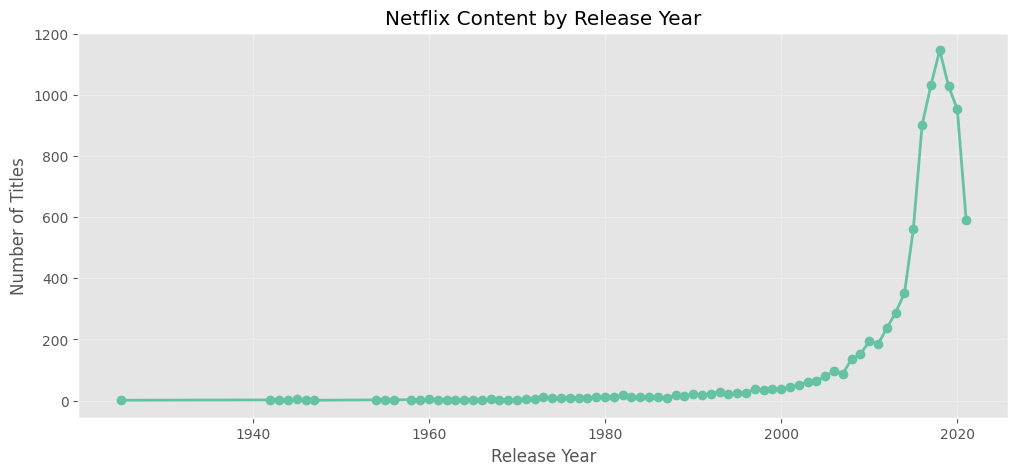

In [52]:

# Titles released each year
release_year = df['release_year'].value_counts().sort_index()

plt.figure(figsize=(12,5))

plt.plot(
    release_year.index,
    release_year.values,
    marker='o',
    linewidth=2
)

plt.title("Netflix Content by Release Year")
plt.xlabel("Release Year")
plt.ylabel("Number of Titles")
plt.grid(alpha=0.3)

plt.show()

In [53]:
print(f"Highest number of releases: {release_year.max()} titles in {release_year.idxmax()}")

Highest number of releases: 1147 titles in 2018


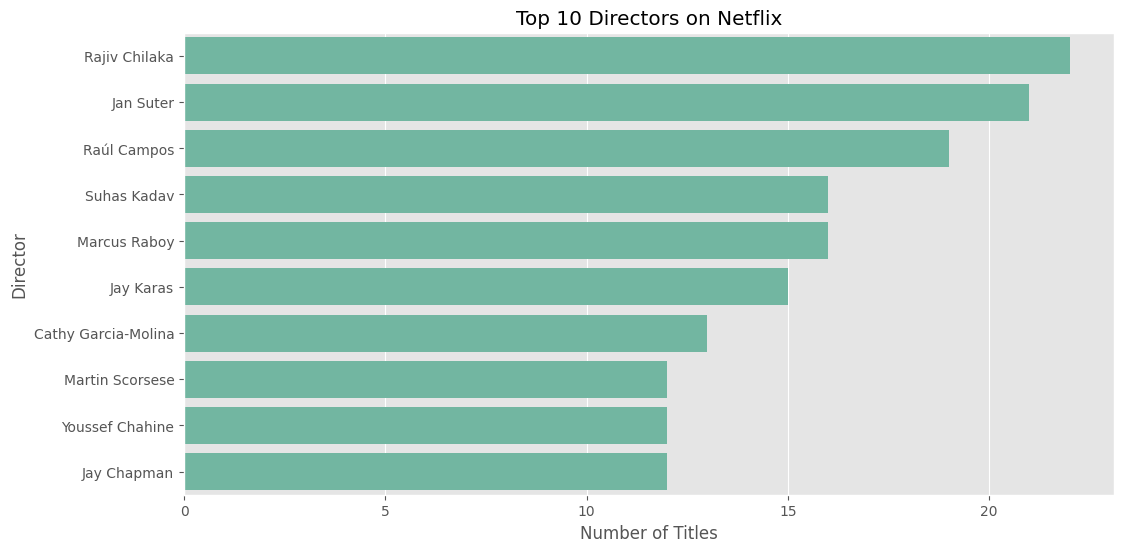

In [54]:
director_df = (
    df.assign(director=df['director'].str.split(', '))
      .explode('director')
)

top_directors = (
    director_df['director']
    .dropna()
    .value_counts()
    .head(10)
)

plt.figure(figsize=(12,6))

sns.barplot(
    x=top_directors.values,
    y=top_directors.index
)

plt.title("Top 10 Directors on Netflix")
plt.xlabel("Number of Titles")
plt.ylabel("Director")

plt.show()

In [56]:
print("Top Director:", top_directors.idxmax())
print("Titles Directed:", top_directors.max())

Top Director: Rajiv Chilaka
Titles Directed: 22


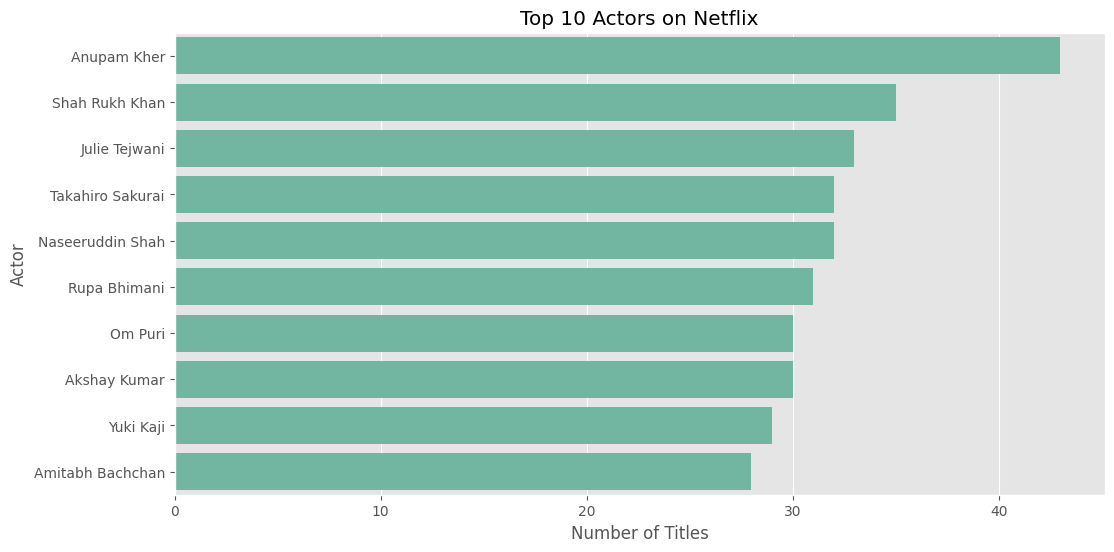

In [57]:
cast_df = (
    df.assign(cast=df['cast'].str.split(', '))
      .explode('cast')
)

top_cast = (
    cast_df['cast']
    .dropna()
    .value_counts()
    .head(10)
)

plt.figure(figsize=(12,6))

sns.barplot(
    x=top_cast.values,
    y=top_cast.index
)

plt.title("Top 10 Actors on Netflix")
plt.xlabel("Number of Titles")
plt.ylabel("Actor")

plt.show()

In [58]:
print("Most Featured Actor:", top_cast.idxmax())
print("Titles:", top_cast.max())

Most Featured Actor: Anupam Kher
Titles: 43


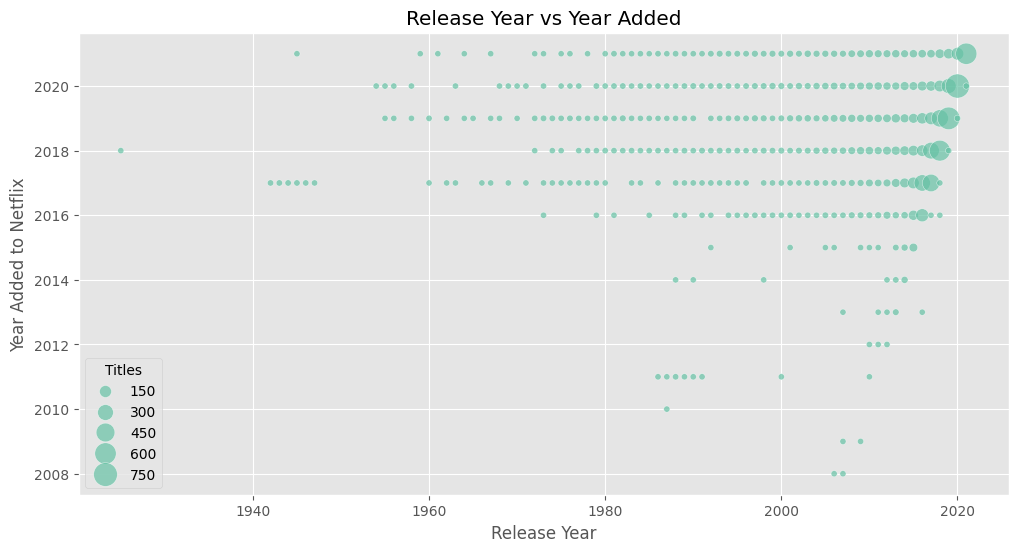

In [59]:
year_compare = (
    df.groupby(['release_year','Year Added'])
      .size()
      .reset_index(name='Titles')
)

plt.figure(figsize=(12,6))

sns.scatterplot(
    data=year_compare,
    x='release_year',
    y='Year Added',
    size='Titles',
    sizes=(20,300),
    alpha=0.7
)

plt.title("Release Year vs Year Added")
plt.xlabel("Release Year")
plt.ylabel("Year Added to Netflix")

plt.show()

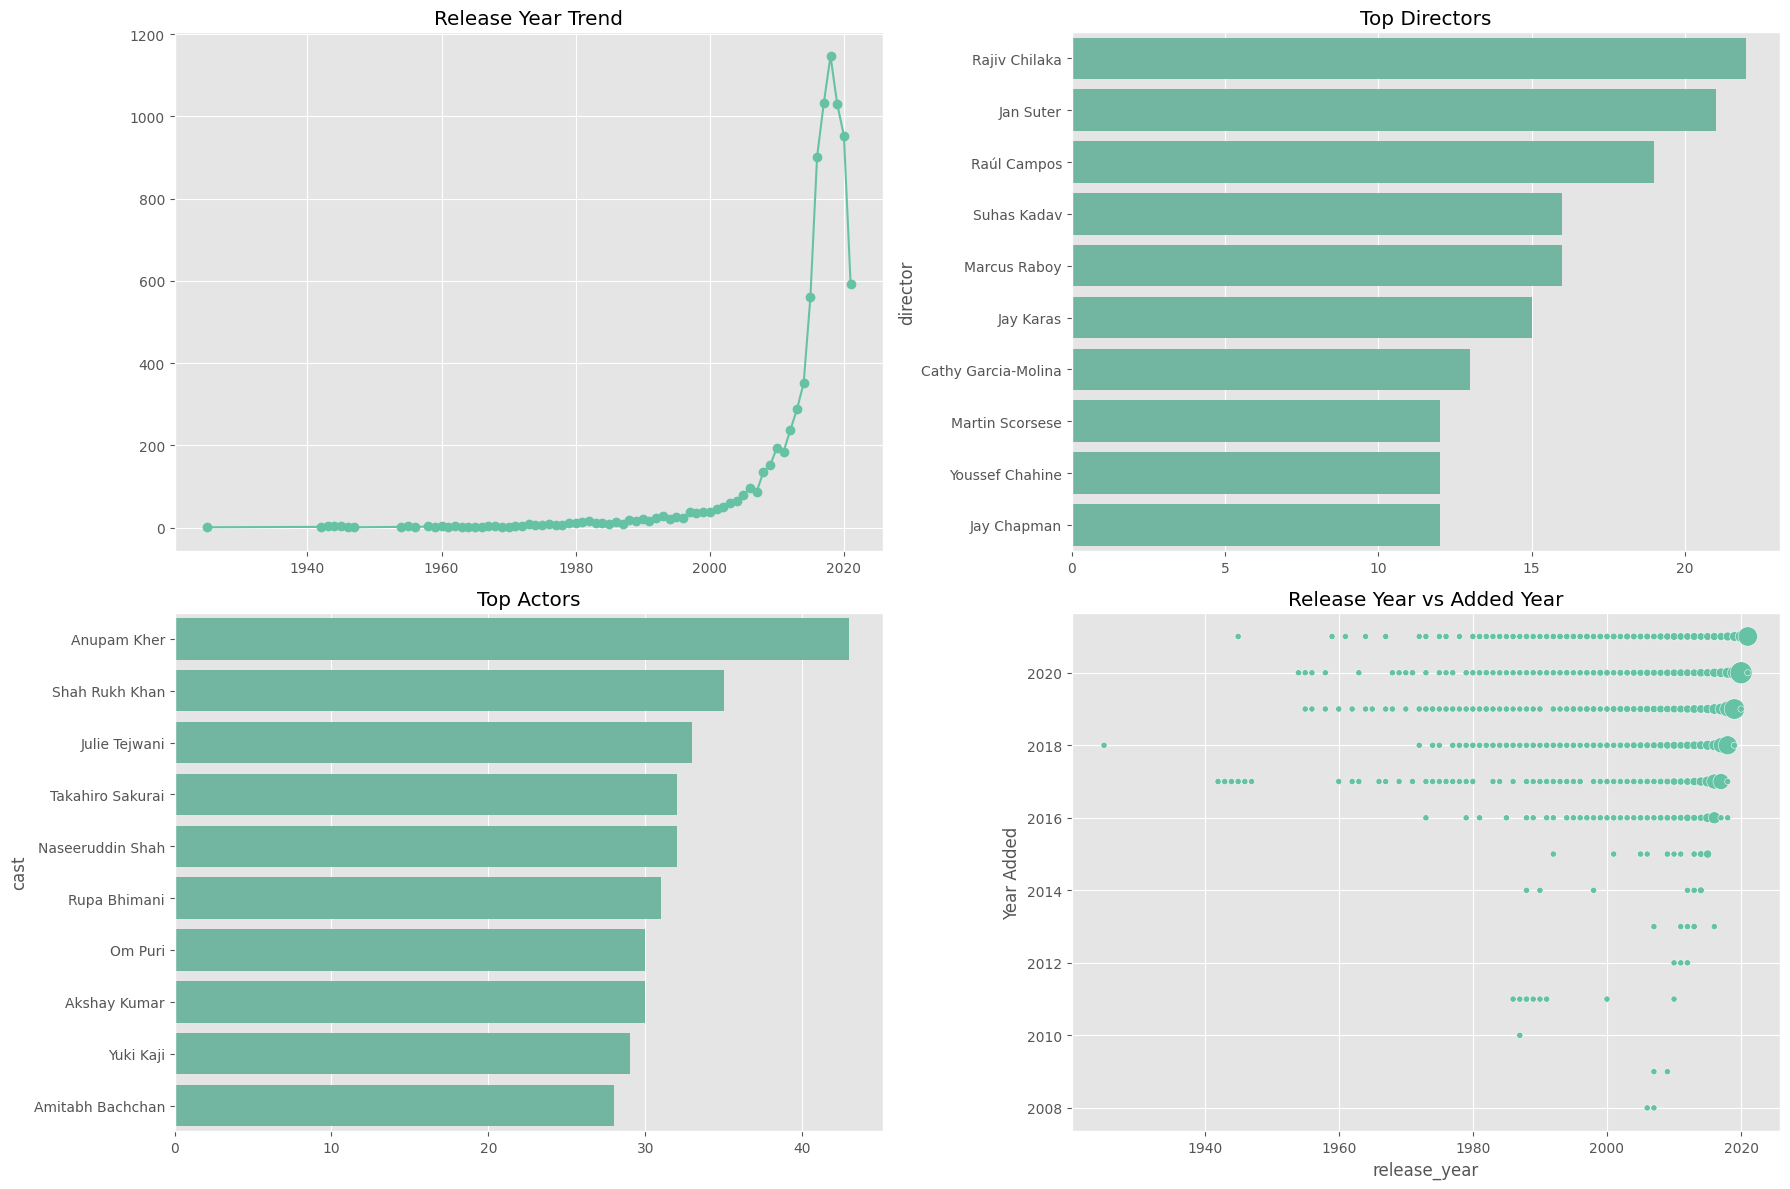

In [60]:
fig, axes = plt.subplots(2,2,figsize=(18,12))

# Release Year
axes[0,0].plot(
    release_year.index,
    release_year.values,
    marker='o'
)
axes[0,0].set_title("Release Year Trend")

# Directors
sns.barplot(
    x=top_directors.values,
    y=top_directors.index,
    ax=axes[0,1]
)
axes[0,1].set_title("Top Directors")

# Actors
sns.barplot(
    x=top_cast.values,
    y=top_cast.index,
    ax=axes[1,0]
)
axes[1,0].set_title("Top Actors")

# Release vs Added
sns.scatterplot(
    data=year_compare,
    x='release_year',
    y='Year Added',
    size='Titles',
    sizes=(20,250),
    ax=axes[1,1],
    legend=False
)

axes[1,1].set_title("Release Year vs Added Year")

plt.tight_layout()

plt.show()

In [62]:
print("="*70)
print("🎬 TIME & PEOPLE ANALYSIS")
print("="*70)

print(f"📅 Peak Release Year      : {release_year.idxmax()} ({release_year.max()} titles)")
print(f"🎥 Top Director           : {top_directors.idxmax()} ({top_directors.max()} titles)")
print(f"🎭 Most Featured Actor    : {top_cast.idxmax()} ({top_cast.max()} titles)")
print(f"📺 Oldest Release         : {df['release_year'].min()}")
print(f"🚀 Latest Release         : {df['release_year'].max()}")

🎬 TIME & PEOPLE ANALYSIS
📅 Peak Release Year      : 2018 (1147 titles)
🎥 Top Director           : Rajiv Chilaka (22 titles)
🎭 Most Featured Actor    : Anupam Kher (43 titles)
📺 Oldest Release         : 1925
🚀 Latest Release         : 2021


# ***Advanced Analytics & Business Insights***

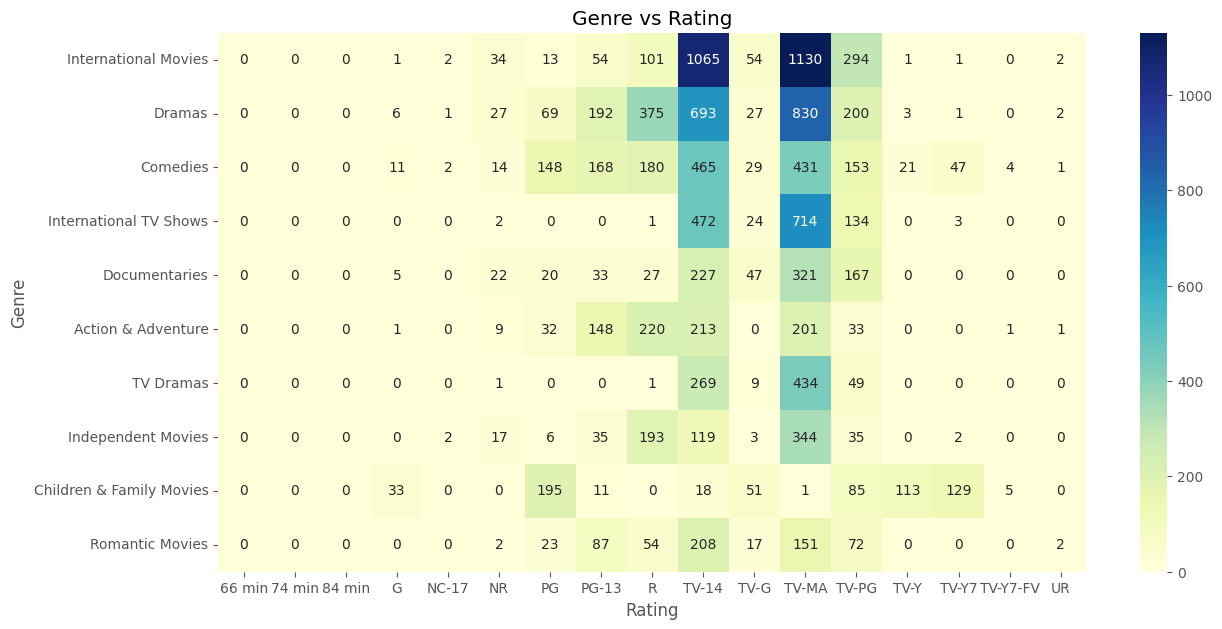

In [63]:
# Split genres into individual rows
genre_rating = (
    df.assign(listed_in=df['listed_in'].str.split(', '))
      .explode('listed_in')
)

heatmap_data = pd.crosstab(
    genre_rating['listed_in'],
    genre_rating['rating']
)

# Top 10 Genres
heatmap_data = heatmap_data.loc[
    genre_rating['listed_in'].value_counts().head(10).index
]

plt.figure(figsize=(14,7))

sns.heatmap(
    heatmap_data,
    annot=True,
    fmt='d',
    cmap='YlGnBu'
)

plt.title("Genre vs Rating")
plt.xlabel("Rating")
plt.ylabel("Genre")

plt.show()

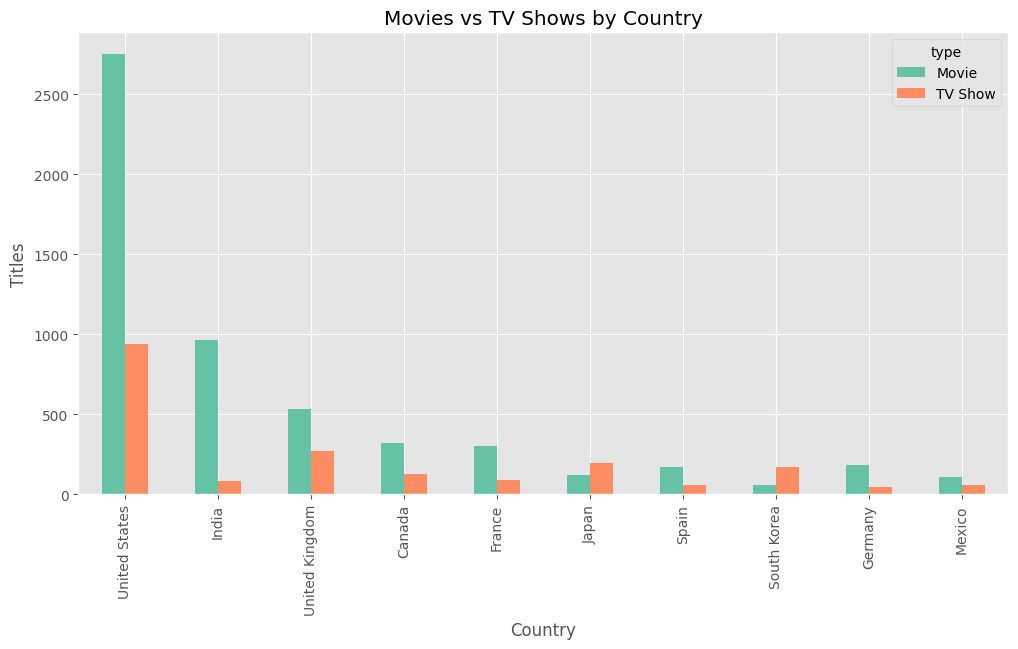

In [64]:
country_type = (
    df.assign(country=df['country'].str.split(', '))
      .explode('country')
      .groupby(['country','type'])
      .size()
      .unstack(fill_value=0)
)

top10 = country_type.sum(axis=1).nlargest(10).index

country_type.loc[top10].plot(
    kind='bar',
    figsize=(12,6)
)

plt.title("Movies vs TV Shows by Country")
plt.xlabel("Country")
plt.ylabel("Titles")

plt.show()

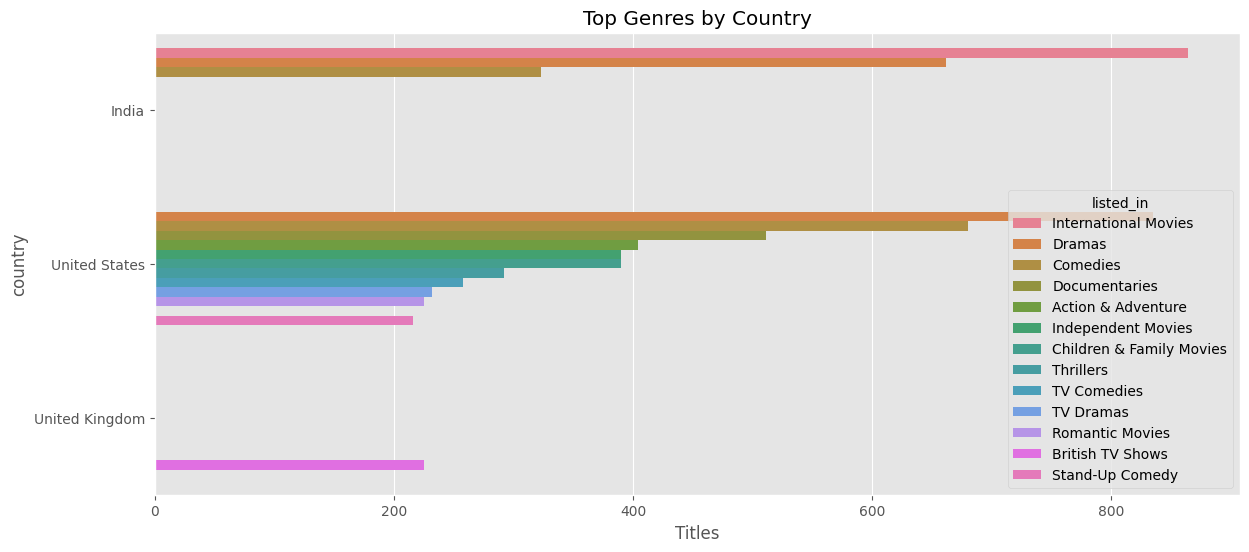

In [65]:
genre_country = (
    df.assign(
        country=df['country'].str.split(', '),
        listed_in=df['listed_in'].str.split(', ')
    )
    .explode('country')
    .explode('listed_in')
)

top_country_genres = (
    genre_country
    .groupby(['country','listed_in'])
    .size()
    .reset_index(name='Titles')
)

top_country_genres = top_country_genres.sort_values(
    'Titles',
    ascending=False
).head(15)

plt.figure(figsize=(14,6))

sns.barplot(
    data=top_country_genres,
    x='Titles',
    y='country',
    hue='listed_in'
)

plt.title("Top Genres by Country")

plt.show()

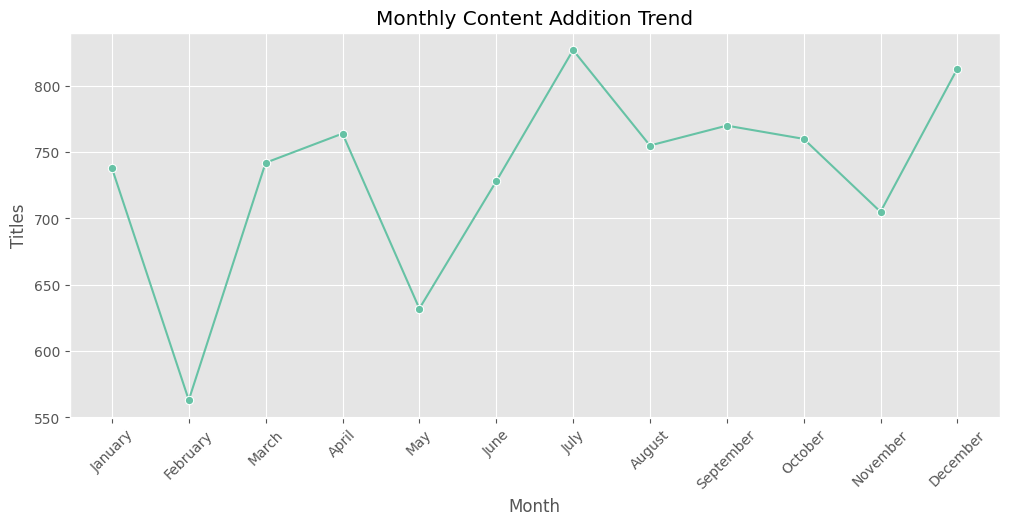

In [68]:
month_order = [
    "January","February","March","April",
    "May","June","July","August",
    "September","October","November","December"
]

monthly = (
    df['Month Added']
    .value_counts()
    .reindex(month_order)
)

plt.figure(figsize=(12,5))

sns.lineplot(
    x=monthly.index,
    y=monthly.values,
    marker='o'
)

plt.xticks(rotation=45)

plt.title("Monthly Content Addition Trend")
plt.xlabel("Month")
plt.ylabel("Titles")

plt.show()

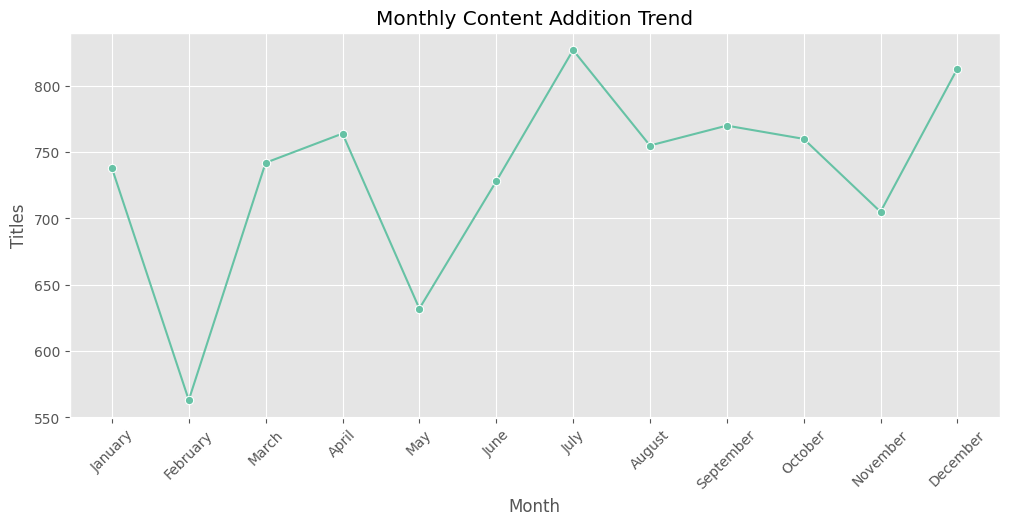

In [69]:
month_order = [
    "January","February","March","April",
    "May","June","July","August",
    "September","October","November","December"
]

monthly = (
    df['Month Added']
    .value_counts()
    .reindex(month_order)
)

plt.figure(figsize=(12,5))

sns.lineplot(
    x=monthly.index,
    y=monthly.values,
    marker='o'
)

plt.xticks(rotation=45)

plt.title("Monthly Content Addition Trend")
plt.xlabel("Month")
plt.ylabel("Titles")

plt.show()

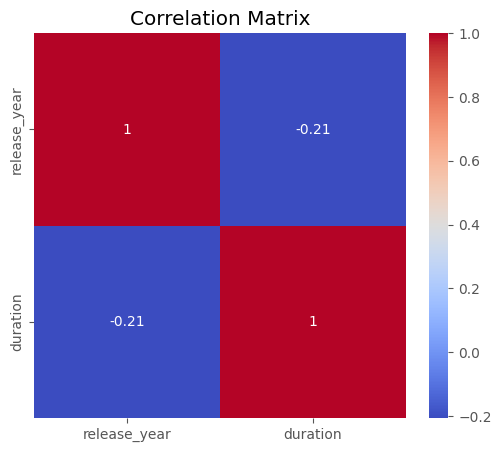

In [70]:
numeric = movies_df[['release_year','duration']]

plt.figure(figsize=(6,5))

sns.heatmap(
    numeric.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Matrix")

plt.show()

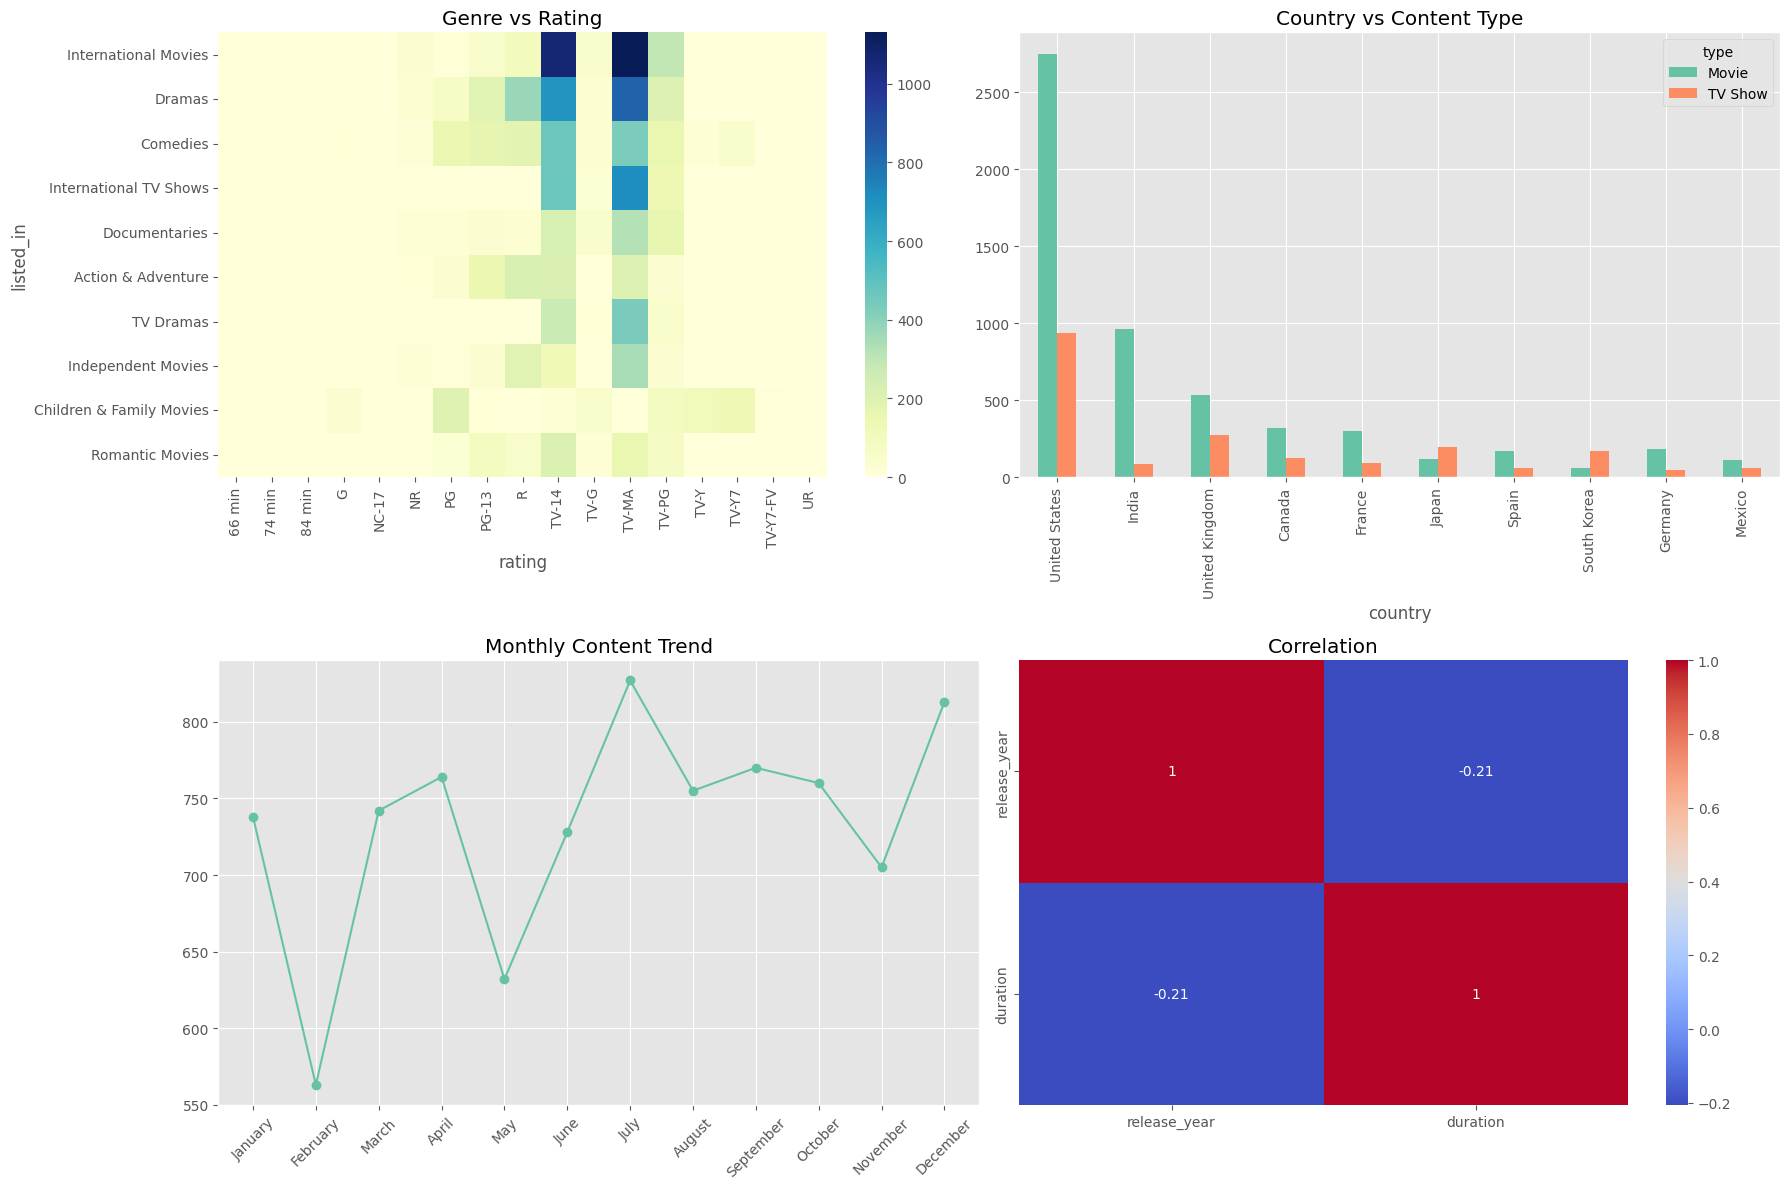

In [71]:
fig, axes = plt.subplots(2,2,figsize=(18,12))

# Heatmap
sns.heatmap(
    heatmap_data,
    cmap='YlGnBu',
    ax=axes[0,0]
)
axes[0,0].set_title("Genre vs Rating")

# Country Comparison
country_type.loc[top10].plot(
    kind='bar',
    ax=axes[0,1]
)
axes[0,1].set_title("Country vs Content Type")

# Monthly Trend
axes[1,0].plot(
    monthly.index,
    monthly.values,
    marker='o'
)
axes[1,0].tick_params(axis='x', rotation=45)
axes[1,0].set_title("Monthly Content Trend")

# Correlation
sns.heatmap(
    numeric.corr(),
    annot=True,
    cmap='coolwarm',
    ax=axes[1,1]
)
axes[1,1].set_title("Correlation")

plt.tight_layout()

plt.show()

In [72]:
print("="*70)
print("📊 ADVANCED BUSINESS INSIGHTS")
print("="*70)

print(f"🏆 Top Producing Country      : {country_type.sum(axis=1).idxmax()}")
print(f"🎭 Most Popular Genre         : {top_genres.idxmax()}")
print(f"⭐ Most Common Rating         : {df['rating'].mode()[0]}")
print(f"📅 Peak Content Addition Year : {yearly_content.idxmax()}")
print(f"📈 Peak Content Month         : {monthly.idxmax()}")
print(f"🎥 Top Director              : {top_directors.idxmax()}")
print(f"🎬 Most Featured Actor       : {top_cast.idxmax()}")
print(f"📺 Total Countries           : {country_type.shape[0]}")
print(f"🎞️ Total Genres              : {genre_df['listed_in'].nunique()}")
print("="*70)

📊 ADVANCED BUSINESS INSIGHTS
🏆 Top Producing Country      : United States
🎭 Most Popular Genre         : International Movies
⭐ Most Common Rating         : TV-MA
📅 Peak Content Addition Year : 2019.0
📈 Peak Content Month         : July
🎥 Top Director              : Rajiv Chilaka
🎬 Most Featured Actor       : Anupam Kher
📺 Total Countries           : 127
🎞️ Total Genres              : 42


In [73]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

In [74]:
df = pd.read_csv("netflix_titles.csv")

In [76]:
df["date_added"] = pd.to_datetime(df["date_added"], format='mixed', errors='coerce')

df["Year Added"] = df["date_added"].dt.year
df["Month Added"] = df["date_added"].dt.month_name()

In [78]:
country_df = (
    df.assign(country=df["country"].str.split(", "))
      .explode("country")
)

genre_df = (
    df.assign(listed_in=df["listed_in"].str.split(", "))
      .explode("listed_in")
)

movies_df = df[df["type"]=="Movie"].copy()
# Clean 'duration' for movies: remove ' min', convert to numeric, drop NaNs, then to int
movies_df["duration"] = movies_df["duration"].str.replace(" min","", regex=False)
movies_df["duration"] = pd.to_numeric(movies_df["duration"], errors='coerce')
movies_df.dropna(subset=['duration'], inplace=True)
movies_df["duration"] = movies_df["duration"].astype(int)

tv_df = df[df["type"]=="TV Show"].copy()
# Clean 'duration' for TV shows: remove ' Seasons'/' Season', convert to numeric, drop NaNs, then to int
tv_df["duration"] = (
    tv_df["duration"]
    .str.replace(" Seasons","", regex=False)
    .str.replace(" Season","", regex=False)
)
tv_df["duration"] = pd.to_numeric(tv_df["duration"], errors='coerce')
tv_df.dropna(subset=['duration'], inplace=True)
tv_df["duration"] = tv_df["duration"].astype(int)